# Case Study: Phân Đoạn Tổn Thương Da Với DeepLabv3+

---
## 1. Khởi tạo môi trường và cố định seed


In [1]:
import os
import math
import random
import time
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
import torchvision.models as models

import warnings
warnings.filterwarnings('ignore')

# Kiểm tra thiết bị phần cứng
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()} (Device: {device})")

# Hàm cố định Seed để đảm bảo tính tái lập (Reproducibility)
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
print("Đã cố định Random Seed = 42")


d:\miniconda3\envs\seg_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch Version : 2.7.1+cu118
CUDA Available  : True (Device: cuda)
Đã cố định Random Seed = 42


---
## 2. Chuẩn bị dữ liệu và Data Augmentation

Dữ liệu ảnh soi da liễu đã được tiền xử lý và lưu dưới dạng các file numpy (`.npy`) giúp nạp toàn bộ vào RAM để tối ưu tốc độ đọc và huấn luyện.


In [2]:
def color_jitter(img: np.ndarray) -> np.ndarray:
    """Điều chỉnh ngẫu nhiên độ sáng, độ tương phản và sắc độ (Hue/Saturation)."""
    # 1. Brightness & Contrast
    alpha = random.uniform(0.8, 1.2)   # Contrast
    beta = random.uniform(-20, 20)     # Brightness
    img = np.clip(alpha * img.astype(float) + beta, 0, 255).astype(np.uint8)

    # 2. Saturation & Hue trong không gian HSV
    if random.random() > 0.5:
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(float)
        hsv[:, :, 0] = (hsv[:, :, 0] + random.uniform(-10, 10)) % 180  # Hue
        hsv[:, :, 1] = np.clip(hsv[:, :, 1] * random.uniform(0.8, 1.2), 0, 255)  # Saturation
        img = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

    return img


def random_rotate_and_crop(img: np.ndarray, mask: np.ndarray, img_size=(256, 256)):
    """Xoay tự do góc (-45 đến +45 độ) và Random Crop & Resize đồng bộ."""
    h, w = img_size
    # Random Rotate
    if random.random() > 0.5:
        angle = random.uniform(-45, 45)
        M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
        mask = cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT_101)

    # Random Crop & Resize
    if random.random() > 0.5:
        scale = random.uniform(0.8, 1.0)
        new_h, new_w = int(h * scale), int(w * scale)
        top = random.randint(0, h - new_h)
        left = random.randint(0, w - new_w)

        img = img[top:top + new_h, left:left + new_w]
        mask = mask[top:top + new_h, left:left + new_w]

        img = cv2.resize(img, (w, h), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

    return img, mask


def apply_augmentations(img: np.ndarray, mask: np.ndarray):
    """Tổng hợp toàn bộ các phép biến đổi data augmentation khi training."""
    # 1. Horizontal Flip
    if random.random() > 0.5:
        img = np.fliplr(img).copy()
        mask = np.fliplr(mask).copy()

    # 2. Vertical Flip
    if random.random() > 0.5:
        img = np.flipud(img).copy()
        mask = np.flipud(mask).copy()

    # 3. Transpose (Đổi trục X, Y)
    if random.random() > 0.5:
        img = np.transpose(img, (1, 0, 2)).copy()
        mask = np.transpose(mask, (1, 0)).copy()

    # 4. Random 90-degree Rotation
    k = random.choice([0, 1, 2, 3])
    if k > 0:
        img = np.rot90(img, k, (0, 1)).copy()
        mask = np.rot90(mask, k, (0, 1)).copy()

    # 5. Rotation tự do & Random Cropping
    img, mask = random_rotate_and_crop(img, mask)

    # 6. Color Jitter (Chỉ áp dụng lên ảnh RGB)
    if random.random() > 0.5:
        img = color_jitter(img)

    return img, mask


In [3]:
PROJECT_ROOT = Path().resolve().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "2"

class FastSkinDataset(Dataset):
    """Dataset nạp sẵn toàn bộ dữ liệu vào RAM để tối ưu I/O đĩa."""
    def __init__(self, data_dir, is_train=False):
        self.is_train = is_train

        images_path = os.path.join(data_dir, "images.npy")
        masks_path = os.path.join(data_dir, "masks.npy")
        ids_path = os.path.join(data_dir, "image_ids.npy")

        self.images = np.load(images_path)
        self.masks = np.load(masks_path) if os.path.exists(masks_path) else None
        self.image_ids = np.load(ids_path) if os.path.exists(ids_path) else None

        # Chuẩn hóa ImageNet Mean & Std
        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]

        if self.masks is not None:
            mask = self.masks[idx]

            # Áp dụng Augmentation khi Training
            if self.is_train:
                image, mask = apply_augmentations(image, mask)

            # Chuẩn hóa ảnh: (H, W, 3) -> (3, H, W) trong khoảng [0, 1] và trừ Mean/Std
            image = (image.astype(np.float32) / 255.0 - self.mean) / self.std
            image = torch.from_numpy(image).permute(2, 0, 1).float()
            mask = torch.from_numpy(mask).float().unsqueeze(0)

            return image, mask

        # Test Inference (không có mask)
        image = (image.astype(np.float32) / 255.0 - self.mean) / self.std
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        sample_id = self.image_ids[idx] if self.image_ids is not None else str(idx)
        return image, sample_id


def get_dataloaders(processed_base=DATA_DIR, batch_size=16, num_workers=0):
    """Tạo DataLoaders cho các tập Train, Validation và Test."""
    train_loader = DataLoader(
        FastSkinDataset(os.path.join(processed_base, "train_256"), is_train=True),
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False,
        drop_last=True
    )

    val_loader = DataLoader(
        FastSkinDataset(os.path.join(processed_base, "val_256"), is_train=False),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False,
        drop_last=False
    )

    test_loader = DataLoader(
        FastSkinDataset(os.path.join(processed_base, "test_256"), is_train=False),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False,
        drop_last=False
    )

    return train_loader, val_loader, test_loader


---
## 3. Khởi tạo DataLoaders và trực quan hoá mẫu dữ liệu


Số lượng mẫu: Train = 1815, Val = 259, Test = 520
Images Shape       : torch.Size([16, 3, 256, 256]) (dtype: torch.float32)
Masks Shape        : torch.Size([16, 1, 256, 256]) (dtype: torch.float32)
Mask Unique Values : [0.0, 1.0]


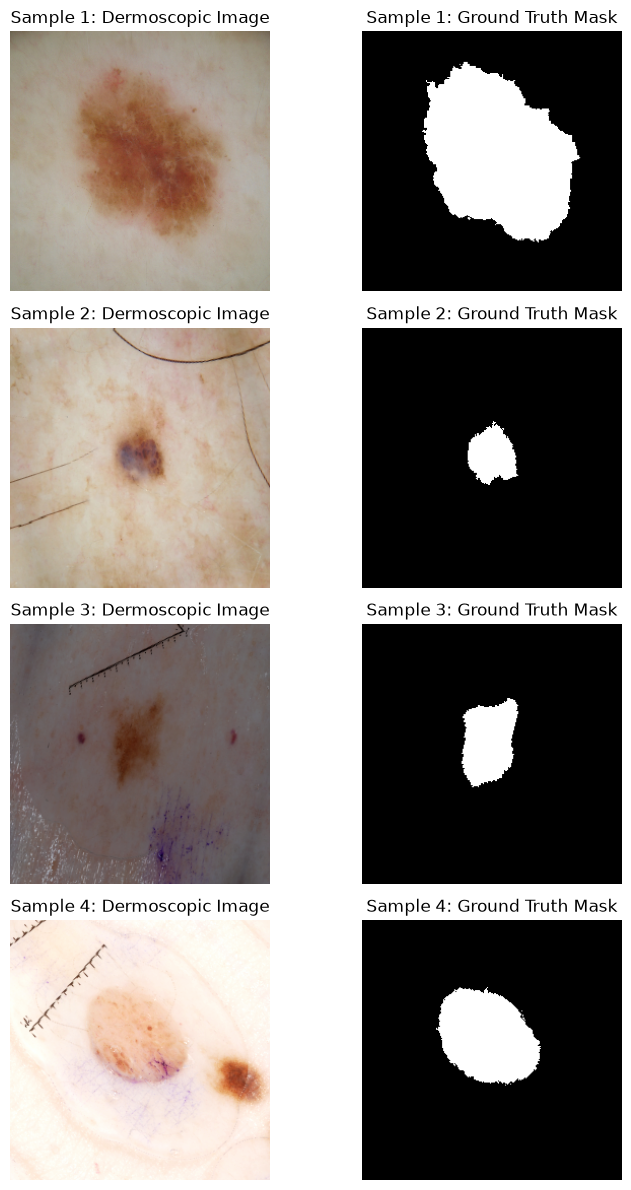

In [4]:
train_loader, val_loader, test_loader = get_dataloaders(batch_size=16, num_workers=0)
print(f"Số lượng mẫu: Train = {len(train_loader.dataset)}, Val = {len(val_loader.dataset)}, Test = {len(test_loader.dataset)}")

# Lấy 1 batch để kiểm tra shape và trực quan hóa
images_batch, masks_batch = next(iter(train_loader))
print(f"Images Shape       : {images_batch.shape} (dtype: {images_batch.dtype})")
print(f"Masks Shape        : {masks_batch.shape} (dtype: {masks_batch.dtype})")
print(f"Mask Unique Values : {torch.unique(masks_batch).tolist()}")

# Trực quan hóa 4 mẫu
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(4, 2, figsize=(8, 12))
for i in range(4):
    img = images_batch[i].permute(1, 2, 0).numpy()
    img = np.clip(img * std + mean, 0, 1)
    mask = masks_batch[i].squeeze().numpy()

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Sample {i+1}: Dermoscopic Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(f"Sample {i+1}: Ground Truth Mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


## 4. Kiến trúc DeepLabv3+: Encoder-Decoder với Atrous Separable Convolution

In [9]:
class AtrousSeparableConv(nn.Module):
    """
    Depthwise Separable Convolution kết hợp Atrous Rate:
    1. Depthwise Conv: Quét độc lập từng kênh không gian với dilation=r.
    2. Pointwise Conv: Tích chập 1x1 trộn thông tin và biến đổi số kênh.
    """
    def __init__(self, in_channels: int, out_channels: int, dilation: int = 1):
        super().__init__()
        self.depthwise = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size=3,
            padding=dilation,
            dilation=dilation,
            groups=in_channels,
            bias=False,
        )
        self.bn_depthwise = nn.BatchNorm2d(in_channels)
        self.relu_depthwise = nn.ReLU(inplace=True)

        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn_pointwise = nn.BatchNorm2d(out_channels)
        self.relu_pointwise = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.depthwise(x)
        x = self.bn_depthwise(x)
        x = self.relu_depthwise(x)
        x = self.pointwise(x)
        x = self.bn_pointwise(x)
        x = self.relu_pointwise(x)
        return x

In [10]:
class ASPPPooling(nn.Module):
    """
    Nhánh Image-Level Features (Global Average Pooling):
    Nén không gian toàn ảnh qua GAP, chiếu qua Conv 1x1 + BN + ReLU,
    sau đó Bilinear Upsampling trở lại kích thước feature map.
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        size = x.shape[2:]
        feat = self.gap(x)
        feat = self.conv(feat)
        return F.interpolate(feat, size=size, mode="bilinear", align_corners=False)

In [11]:
class DeepLabv3PlusASPP(nn.Module):
    """
    - Nhánh 1: Conv 1x1 (256 filters)
    - Nhánh 2: Atrous Separable Conv 3x3 (rate=6, 256 filters)
    - Nhánh 3: Atrous Separable Conv 3x3 (rate=12, 256 filters)
    - Nhánh 4: Atrous Separable Conv 3x3 (rate=18, 256 filters)
    - Nhánh 5: Image-level pooling
    Sau đó Concatenate -> Conv 1x1 (256) -> BN -> ReLU -> Dropout(0.5).
    """

    def __init__(
        self,
        in_channels: int = 2048,
        atrous_rates: list = [6, 12, 18],
        out_channels: int = 256,
    ):
        super().__init__()
        modules = []

        # Nhánh 1: Conv 1x1 thông thường
        modules.append(
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            )
        )

        # Nhánh 2, 3, 4: Atrous Separable Convolutions với rates = [6, 12, 18]
        for rate in atrous_rates:
            modules.append(
                AtrousSeparableConv(in_channels, out_channels, dilation=rate)
            )

        # Nhánh 5: Image-level pooling
        modules.append(ASPPPooling(in_channels, out_channels))

        self.branches = nn.ModuleList(modules)

        # Feature Fusion từ 5 nhánh: 256 * 5 = 1280 channels -> 256 channels
        self.project = nn.Sequential(
            nn.Conv2d(
                len(self.branches) * out_channels,
                out_channels,
                kernel_size=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        res = [branch(x) for branch in self.branches]
        res = torch.cat(res, dim=1)
        return self.project(res)

In [12]:
class DeepLabv3PlusDecoder(nn.Module):
    """
    Decoder gọn nhẹ của DeepLabv3+ khôi phục đường biên sắc nét:
    1. Nhánh nông: Chiếu đặc trưng layer1 (256 kênh) xuống đúng 48 kênh bằng Conv 1x1 + BN + ReLU.
    2. Nhánh sâu: Upsample đặc trưng Encoder lên 4 lần (Bilinear) về kích thước (H/4, W/4).
    3. Ghép kênh: Nối 256 kênh ngữ nghĩa + 48 kênh tầng thấp = 304 kênh.
    4. Tinh chỉnh: Đưa qua hai lớp Conv 3x3 (256 filters, BN, ReLU, Dropout 0.1).
    5. Phân lớp & Upsample: Conv 1x1 ra num_classes rồi Bilinear Upsample 4 lần về kích thước ảnh gốc.
    """
    def __init__(self, low_level_channels: int = 256, encoder_channels: int = 256, num_classes: int = 1):
        super().__init__()
        # Nén kênh đặc trưng tầng thấp từ 256 xuống 48 channels
        self.project_low_level = nn.Sequential(
            nn.Conv2d(low_level_channels, 48, kernel_size=1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )

        # Hai lớp Conv 3x3 tinh chỉnh (304 channels -> 256 channels)
        self.refine = nn.Sequential(
            nn.Conv2d(encoder_channels + 48, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1)
        )

        # Classifier Head xuất logits
        self.classifier = nn.Conv2d(256, num_classes, kernel_size=1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0.0)

    def forward(self, encoder_feat: torch.Tensor, low_level_feat: torch.Tensor, input_size: tuple) -> torch.Tensor:
        # 1. Nén đặc trưng tầng thấp xuống 48 kênh
        low_level_feat = self.project_low_level(low_level_feat)

        # 2. Phóng đại đặc trưng Encoder lên 4 lần để khớp kích thước (H/4, W/4)
        encoder_feat = F.interpolate(
            encoder_feat,
            size=low_level_feat.shape[2:],
            mode='bilinear',
            align_corners=False
        )

        # 3. Ghép kênh: (B, 256, H/4, W/4) + (B, 48, H/4, W/4) -> (B, 304, H/4, W/4)
        concat_feat = torch.cat([encoder_feat, low_level_feat], dim=1)

        # 4. Tinh chỉnh qua hai lớp Conv 3x3
        refined_feat = self.refine(concat_feat)

        # 5. Phân lớp logits và Bilinear Upsample 4 lần về kích thước ảnh gốc
        logits = self.classifier(refined_feat)
        logits = F.interpolate(logits, size=input_size, mode='bilinear', align_corners=False)
        return logits


In [14]:
class DeepLabv3Plus(nn.Module):
    """
    Mô hình DeepLabv3+ hoàn chỉnh kết hợp:
    - Backbone ResNet-50 / ResNet-101 (Multi-Grid MG=(1, 2, 4) ở layer4)
    - Trích xuất đặc trưng tầng thấp (layer1, 256 kênh, spatial H/4 x W/4)
    - Encoder ASPP Module với Atrous Separable Convolutions
    - Decoder gọn nhẹ (nén 48 kênh + ghép kênh + 2x Conv 3x3 + Upsampling 4x)
    """
    def __init__(
        self,
        backbone_name: str = "resnet50",
        pretrained: bool = True,
        num_classes: int = 1,
        output_stride: int = 16,
        multi_grid: tuple = (1, 2, 4)
    ):
        super().__init__()
        self.backbone_name = backbone_name
        self.output_stride = output_stride
        self.multi_grid = multi_grid

        # 1. Khởi tạo ResNet backbone
        if backbone_name == "resnet50":
            weights = models.ResNet50_Weights.DEFAULT if pretrained else None
            resnet = models.resnet50(weights=weights)
            low_level_channels = 256   # layer1
            in_channels = 2048          # layer4
        elif backbone_name == "resnet101":
            weights = models.ResNet101_Weights.DEFAULT if pretrained else None
            resnet = models.resnet101(weights=weights)
            low_level_channels = 256
            in_channels = 2048
        elif backbone_name == "resnet34":
            weights = models.ResNet34_Weights.DEFAULT if pretrained else None
            resnet = models.resnet34(weights=weights)
            low_level_channels = 64
            in_channels = 512
        else:
            raise ValueError(f"Không hỗ trợ backbone: {backbone_name}")

        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool

        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        # 2. Cấu hình Output Stride & Multi-Grid trong Backbone
        if output_stride == 16:
            self._apply_multi_grid_to_layer4(base_dilation=2, multi_grid=multi_grid)
            aspp_rates = [6, 12, 18]
        elif output_stride == 8:
            self._modify_layer_dilation(self.layer3, dilation=2)
            self._apply_multi_grid_to_layer4(base_dilation=4, multi_grid=multi_grid)
            aspp_rates = [12, 24, 36]
        else:
            raise ValueError(f"Output stride phải là 8 hoặc 16, nhận được: {output_stride}")

        # 3. Encoder: ASPP Module với Atrous Separable Conv
        self.encoder_aspp = DeepLabv3PlusASPP(
            in_channels=in_channels,
            atrous_rates=aspp_rates,
            out_channels=256
        )

        # 4. Decoder: Nén tầng thấp xuống 48 kênh, ghép với đặc trưng sâu và tinh chỉnh biên
        self.decoder = DeepLabv3PlusDecoder(
            low_level_channels=low_level_channels,
            encoder_channels=256,
            num_classes=num_classes
        )

    def _modify_layer_dilation(self, layer, dilation: int):
        for m in layer.modules():
            if isinstance(m, nn.Conv2d):
                if m.stride == (2, 2):
                    m.stride = (1, 1)
                if m.kernel_size == (3, 3):
                    m.dilation = (dilation, dilation)
                    m.padding = (dilation, dilation)

    def _apply_multi_grid_to_layer4(self, base_dilation: int, multi_grid: tuple):
        """Áp dụng Multi-Grid vào layer4: Rate = base_dilation * r_i."""
        for i, block in enumerate(self.layer4):
            if i == 0:
                if hasattr(block, 'conv2') and block.conv2.stride == (2, 2):
                    block.conv2.stride = (1, 1)
                if hasattr(block, 'downsample') and block.downsample is not None:
                    if isinstance(block.downsample[0], nn.Conv2d) and block.downsample[0].stride == (2, 2):
                        block.downsample[0].stride = (1, 1)

            r_i = multi_grid[min(i, len(multi_grid) - 1)]
            eff_dilation = base_dilation * r_i

            if hasattr(block, 'conv2'):  # Bottleneck block (ResNet50 / 101)
                block.conv2.dilation = (eff_dilation, eff_dilation)
                block.conv2.padding = (eff_dilation, eff_dilation)
            elif hasattr(block, 'conv1'):  # BasicBlock (ResNet34)
                block.conv1.dilation = (eff_dilation, eff_dilation)
                block.conv1.padding = (eff_dilation, eff_dilation)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        input_size = x.shape[2:]

        # Backbone Feature Extraction
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Đặc trưng tầng thấp (Low-level features) ở layer1: (B, 256, H/4, W/4)
        low_level_feat = self.layer1(x)

        x = self.layer2(low_level_feat)
        x = self.layer3(x)
        # Đặc trưng ngữ nghĩa sâu ở layer4 (OS=16): (B, 2048, H/16, W/16)
        high_level_feat = self.layer4(x)

        # Encoder: ASPP Module
        encoder_feat = self.encoder_aspp(high_level_feat)  # (B, 256, H/16, W/16)

        # Decoder: Kết hợp đặc trưng sâu (upsample 4x) và đặc trưng nông (nén 48 kênh)
        logits = self.decoder(encoder_feat, low_level_feat, input_size)  # (B, num_classes, H, W)
        return logits


In [15]:
# Khởi tạo mô hình DeepLabv3+ (ResNet-50 + Multi-Grid + Atrous Separable ASPP + Decoder)
model = DeepLabv3Plus(
    backbone_name="resnet50",
    pretrained=True,
    num_classes=1,
    output_stride=16,
    multi_grid=(1, 2, 4)
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 70)
print(f"Khởi tạo DeepLabv3+ ({model.backbone_name.upper()} + Multi-Grid {model.multi_grid} + Separable ASPP + Decoder)")
print(f"Thiết bị                     : {device}")
print(f"Output Stride                : {model.output_stride}")
print(f"Tổng số tham số             : {total_params:,} (~{total_params/1e6:.2f}M)")
print(f"Số tham số huấn luyện được  : {trainable_params:,} (~{trainable_params/1e6:.2f}M)")
print("=" * 70)

# Kiểm tra forward pass với dummy tensor
dummy_input = torch.randn(2, 3, 256, 256).to(device)
with torch.no_grad():
    dummy_out = model(dummy_input)
print(f"Kiểm thử Tensor Shape: Output = {dummy_out.shape} -> Khớp chuẩn (B, 1, 256, 256)!")


Khởi tạo DeepLabv3+ (RESNET50 + Multi-Grid (1, 2, 4) + Separable ASPP + Decoder)
Thiết bị                     : cuda
Output Stride                : 16
Tổng số tham số             : 27,831,713 (~27.83M)
Số tham số huấn luyện được  : 27,831,713 (~27.83M)
Kiểm thử Tensor Shape: Output = torch.Size([2, 1, 256, 256]) -> Khớp chuẩn (B, 1, 256, 256)!


---
## 5. Loss Function And Evaluation Metrics

- **BCEWithLogitsLoss**: Đánh giá pixel-level classification.
- **Dice Loss**: Trực tiếp tối ưu hóa diện tích giao thoa giữa vùng dự đoán và ground truth tổn thương da.
- **Combined Loss**: $L = \alpha \cdot L_{\text{BCE}} + (1 - \alpha) \cdot L_{\text{Dice}}$ (với $\alpha = 0.5$).
- **Bộ chỉ số y tế chuẩn**: Dice Coefficient (F1), IoU (Jaccard), Sensitivity (Recall), Specificity, Precision, Pixel Accuracy.


In [16]:
bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(pred: torch.Tensor, target: torch.Tensor, smooth: float = 1e-6) -> torch.Tensor:
    """Soft Dice Loss hỗ trợ tính gradient trực tiếp."""
    pred = torch.sigmoid(pred)
    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)

    intersection = (pred * target).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (pred.sum(dim=1) + target.sum(dim=1) + smooth)
    return 1.0 - dice.mean()


def combined_loss(pred: torch.Tensor, target: torch.Tensor, alpha: float = 0.5) -> torch.Tensor:
    """Kết hợp BCEWithLogitsLoss và Soft Dice Loss."""
    return alpha * bce_loss(pred, target) + (1.0 - alpha) * dice_loss(pred, target)


def dice_score(pred: torch.Tensor, target: torch.Tensor, threshold: float = 0.5, smooth: float = 1e-6) -> float:
    """Tính Dice Coefficient cho batch dữ liệu."""
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)

    intersection = (pred * target).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (pred.sum(dim=1) + target.sum(dim=1) + smooth)
    return dice.mean().item()


def compute_all_metrics(pred_mask: np.ndarray, gt_mask: np.ndarray, smooth: float = 1e-6) -> dict:
    """
    Tính toán toàn diện 6 chỉ số đánh giá phân đoạn y tế:
    - Dice / F1 Score
    - IoU / Jaccard Index
    - Sensitivity / Recall
    - Specificity
    - Precision
    - Pixel Accuracy
    """
    pred = (pred_mask > 0).astype(np.float32).flatten()
    gt = (gt_mask > 0).astype(np.float32).flatten()

    tp = np.sum(pred * gt)
    fp = np.sum(pred * (1.0 - gt))
    fn = np.sum((1.0 - pred) * gt)
    tn = np.sum((1.0 - pred) * (1.0 - gt))

    dice = (2.0 * tp + smooth) / (2.0 * tp + fp + fn + smooth)
    iou = (tp + smooth) / (tp + fp + fn + smooth)
    sensitivity = (tp + smooth) / (tp + fn + smooth)
    specificity = (tn + smooth) / (tn + fp + smooth)
    precision = (tp + smooth) / (tp + fp + smooth)
    accuracy = (tp + tn + smooth) / (tp + tn + fp + fn + smooth)

    return {
        "dice": float(dice),
        "iou": float(iou),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "precision": float(precision),
        "accuracy": float(accuracy),
    }


---
## 6. Callbacks và trực quan hóa kết quả


In [17]:
class EarlyStopping:
    """Dừng sớm nếu metric theo dõi không cải thiện sau `patience` epochs."""
    def __init__(self, patience=5, min_delta=1e-4, mode="max", save_path="best_model.pth"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.save_path = save_path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_metric = -float("inf") if mode == "max" else float("inf")

    def __call__(self, current_metric, model, epoch=None, optimizer=None):
        score = current_metric if self.mode == "max" else -current_metric

        if self.best_score is None:
            self.best_score = score
            self.best_metric = current_metric
            self.save_checkpoint(epoch, model, optimizer)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            print(f"EarlyStopping Counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_metric = current_metric
            self.save_checkpoint(epoch, model, optimizer)
            self.counter = 0

    def save_checkpoint(self, epoch, model, optimizer):
        os.makedirs(os.path.dirname(self.save_path), exist_ok=True)
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict() if optimizer else None,
            "best_metric": self.best_metric,
        }
        torch.save(checkpoint, self.save_path)
        print(f"[ĐÃ LƯU BEST CHECKPOINT] -> Best Val Dice: {self.best_metric:.4f} tại: {self.save_path}")


def log_predictions(samples, current_epoch, num_samples=4):
    """
    Tạo ảnh tổng hợp so sánh trực quan 3 cột:
    Cột 1: Ảnh gốc | Cột 2: Ground Truth Mask | Cột 3: Model Prediction
    """
    images, masks, preds = samples
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    num_samples = min(num_samples, len(images))
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 3.5 * num_samples))
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(num_samples):
        # 1. Un-normalize ảnh RGB
        img = images[i].permute(1, 2, 0).numpy()
        img = np.clip((img * std + mean), 0, 1)

        # 2. Lấy mask 2D
        gt = masks[i].squeeze().numpy()
        pred = preds[i].squeeze().numpy()

        # Cột 1: Ảnh gốc
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Sample {i+1}: Input Image", fontsize=11, fontweight="bold")
        axes[i, 0].axis("off")

        # Cột 2: Ground Truth
        axes[i, 1].imshow(gt, cmap="gray")
        axes[i, 1].set_title(f"Sample {i+1}: Ground Truth Mask", fontsize=11, color="green", fontweight="bold")
        axes[i, 1].axis("off")

        # Cột 3: Prediction
        axes[i, 2].imshow(pred, cmap="gray")
        axes[i, 2].set_title(f"Sample {i+1}: DeepLabv3+ Prediction", fontsize=11, color="blue", fontweight="bold")
        axes[i, 2].axis("off")

    plt.suptitle(f"--- VALIDATION PREDICTIONS (EPOCH {current_epoch}) ---", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


---
## 7. Tiến trình huấn luyện và đánh giá


In [18]:
def train_one_epoch(model, loader, optimizer, device, current_epoch, scaler, criterion=combined_loss):
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    pbar = tqdm(enumerate(loader), total=len(loader), desc=f"Train Epoch {current_epoch+1}", leave=False)

    for batch_idx, (images, masks) in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        running_dice += dice_score(outputs.detach(), masks) * batch_size

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "dice": f"{dice_score(outputs.detach(), masks):.4f}",
            "lr": f"{optimizer.param_groups[0]['lr']:.2e}"
        })

    return running_loss / len(loader.dataset), running_dice / len(loader.dataset)


@torch.no_grad()
def validate_one_epoch(model, loader, device, current_epoch, criterion=combined_loss, use_amp=True):
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    val_samples = None

    pbar = tqdm(enumerate(loader), total=len(loader), desc=f"Val Epoch {current_epoch+1}", leave=False)

    for batch_idx, (images, masks) in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        if use_amp and device.type == 'cuda':
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, masks)
        else:
            outputs = model(images)
            loss = criterion(outputs, masks)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        running_dice += dice_score(outputs, masks) * batch_size

        pbar.set_postfix({
            "val_loss": f"{loss.item():.4f}",
            "val_dice": f"{dice_score(outputs, masks):.4f}"
        })

        if batch_idx == 0:
            val_samples = (
                images.cpu(),
                masks.cpu(),
                (torch.sigmoid(outputs) > 0.5).float().cpu()
            )

    return running_loss / len(loader.dataset), running_dice / len(loader.dataset), val_samples


In [19]:
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    device,
    epochs=20,
    patience=5,
    criterion=combined_loss,
    save_dir="../checkpoints/deeplabv3plus",
    use_amp=True
):
    """Toàn bộ vòng lặp huấn luyện, đánh giá, scheduler, early stopping và lưu trữ lịch sử."""
    os.makedirs(save_dir, exist_ok=True)
    best_model_path = os.path.join(save_dir, "best_deeplabv3plus_model.pth")

    early_stopping = EarlyStopping(patience=patience, mode="max", save_path=best_model_path)
    scaler = GradScaler(enabled=(use_amp and device.type == 'cuda'))

    history = {
        "train_loss": [],
        "train_dice": [],
        "val_loss": [],
        "val_dice": [],
        "lr": []
    }

    total_start_time = time.time()
    print(f"Bắt đầu huấn luyện DeepLabv3+ trên: {device} ({epochs} Epochs | Patience: {patience})")
    print("=" * 80)

    for epoch in range(epochs):
        epoch_start_time = time.time()

        # 1. Huấn luyện 1 epoch
        train_loss, train_dice = train_one_epoch(
            model, train_loader, optimizer, device, epoch, scaler, criterion
        )

        # 2. Đánh giá validation 1 epoch
        val_loss, val_dice, val_samples = validate_one_epoch(
            model, val_loader, device, epoch, criterion, use_amp
        )

        # 3. Cập nhật Learning Rate Scheduler
        if scheduler is not None:
            scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]
        epoch_duration = time.time() - epoch_start_time

        # Lưu lịch sử
        history["train_loss"].append(train_loss)
        history["train_dice"].append(train_dice)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)
        history["lr"].append(current_lr)

        # 4. In thông tin Epoch
        print(
            f"Epoch [{epoch+1:02d}/{epochs:02d}] ({epoch_duration:.1f}s) | "
            f"Train Loss: {train_loss:.4f} - Dice: {train_dice:.4f} | "
            f"Val Loss: {val_loss:.4f} - Dice: {val_dice:.4f} | "
            f"LR: {current_lr:.2e}"
        )

        # 5. Kiểm tra Early Stopping và lưu best checkpoint
        early_stopping(val_dice, model, epoch=epoch+1, optimizer=optimizer)
        if early_stopping.early_stop:
            print(f"\nDỪNG SỚM (Early Stopping) tại Epoch {epoch+1}! Metric không tăng sau {patience} epochs.")
            break

    # 6. Hiển thị dự đoán mẫu ở epoch cuối
    if val_samples is not None:
        log_predictions(val_samples, current_epoch=epoch+1)

    total_time = time.time() - total_start_time
    print("=" * 80)
    print(f"Hoàn thành huấn luyện trong {total_time/60:.2f} phút. Best Val Dice: {early_stopping.best_metric:.4f}")

    return history, best_model_path


---
## 8. Cấu hình Hyperparameters và thực thi huấn luyện

DeepLabv3+ áp dụng chiến lược học phân tầng (Differential Learning Rates):
- **Backbone ResNet (Pretrained)**: Learning rate nhỏ (`2.5e-5`) để tinh chỉnh nhẹ nhàng các biểu diễn đã học từ ImageNet.
- **Encoder ASPP & Decoder (Khởi tạo mới)**: Learning rate lớn hơn (`2.5e-4`) để học nhanh các biểu diễn đa tỷ lệ và các phép hòa trộn không gian biên.
- **Polynomial Learning Rate Decay**: Theo đúng công thức paper DeepLabv3+:
$$\text{lr} = \text{base\_lr} \times \left(1 - \frac{\text{iter}}{\text{max\_iter}}\right)^{\text{power}}, \quad \text{power} = 0.9$$


In [20]:
class PolyLRScheduler:
    """Polynomial Learning Rate Decay theo paper DeepLabv3+."""
    def __init__(self, optimizer, base_lrs, max_iters, power=0.9):
        self.optimizer = optimizer
        self.base_lrs = base_lrs
        self.max_iters = max_iters
        self.power = power
        self.current_iter = 0

    def step(self):
        self.current_iter += 1
        factor = (1.0 - min(self.current_iter, self.max_iters) / self.max_iters) ** self.power
        for i, pg in enumerate(self.optimizer.param_groups):
            pg["lr"] = self.base_lrs[i] * factor

    def get_lr(self):
        return [pg["lr"] for pg in self.optimizer.param_groups]


config = {
    "architecture": "DeepLabv3Plus-ResNet50",
    "backbone": "resnet50",
    "output_stride": 16,
    "multi_grid": (1, 2, 4),
    "dataset": "ISIC-256",
    "image_size": 256,
    "batch_size": 16,
    "epochs": 20,
    "patience": 5,
    "backbone_lr": 2.5e-5,
    "head_lr": 2.5e-4,
    "weight_decay": 1e-4,
    "scheduler": "PolyLR",
    "power": 0.9,
    "save_dir": "../checkpoints/deeplabv3plus_resnet50"
}


Bắt đầu huấn luyện DeepLabv3+ trên: cuda (20 Epochs | Patience: 5)


Epoch [01/20] (33.1s) | Train Loss: 0.7863 - Dice: 0.6141 | Val Loss: 2.3540 - Dice: 0.5272 | LR: 2.39e-05
[ĐÃ LƯU BEST CHECKPOINT] -> Best Val Dice: 0.5272 tại: ../checkpoints/deeplabv3plus_resnet50\best_deeplabv3plus_model.pth


Epoch [02/20] (31.0s) | Train Loss: 0.3555 - Dice: 0.7440 | Val Loss: 0.2472 - Dice: 0.8010 | LR: 2.27e-05
[ĐÃ LƯU BEST CHECKPOINT] -> Best Val Dice: 0.8010 tại: ../checkpoints/deeplabv3plus_resnet50\best_deeplabv3plus_model.pth


Epoch [03/20] (35.4s) | Train Loss: 0.2347 - Dice: 0.7984 | Val Loss: 0.1873 - Dice: 0.8393 | LR: 2.16e-05
[ĐÃ LƯU BEST CHECKPOINT] -> Best Val Dice: 0.8393 tại: ../checkpoints/deeplabv3plus_resnet50\best_deeplabv3plus_model.pth


Epoch [04/20] (33.7s) | Train Loss: 0.2063 - Dice: 0.8238 | Val Loss: 0.1971 - Dice: 0.8431 | LR: 2.05e-05
[ĐÃ LƯU BEST CHECKPOINT] -> Best Val Dice: 0.8431 tại: ../checkpoints/deeplabv3plus_resnet50\best_deeplabv3plus_model.pth


...

Epoch [16/20] (57.9s) | Train Loss: 0.1239 - Dice: 0.8893 | Val Loss: 0.1136 - Dice: 0.8986 | LR: 5.87e-06
[ĐÃ LƯU BEST CHECKPOINT] -> Best Val Dice: 0.8986 tại: ../checkpoints/deeplabv3plus_resnet50\best_deeplabv3plus_model.pth


Epoch [17/20] (46.7s) | Train Loss: 0.1181 - Dice: 0.8924 | Val Loss: 0.1196 - Dice: 0.8955 | LR: 4.53e-06
EarlyStopping Counter: 1/5


Epoch [18/20] (47.3s) | Train Loss: 0.1183 - Dice: 0.8927 | Val Loss: 0.1296 - Dice: 0.8913 | LR: 3.15e-06
EarlyStopping Counter: 2/5


Epoch [19/20] (47.2s) | Train Loss: 0.1172 - Dice: 0.8940 | Val Loss: 0.1240 - Dice: 0.8946 | LR: 1.69e-06
EarlyStopping Counter: 3/5


Epoch [20/20] (48.0s) | Train Loss: 0.1124 - Dice: 0.8967 | Val Loss: 0.1184 - Dice: 0.8971 | LR: 0.00e+00
EarlyStopping Counter: 4/5


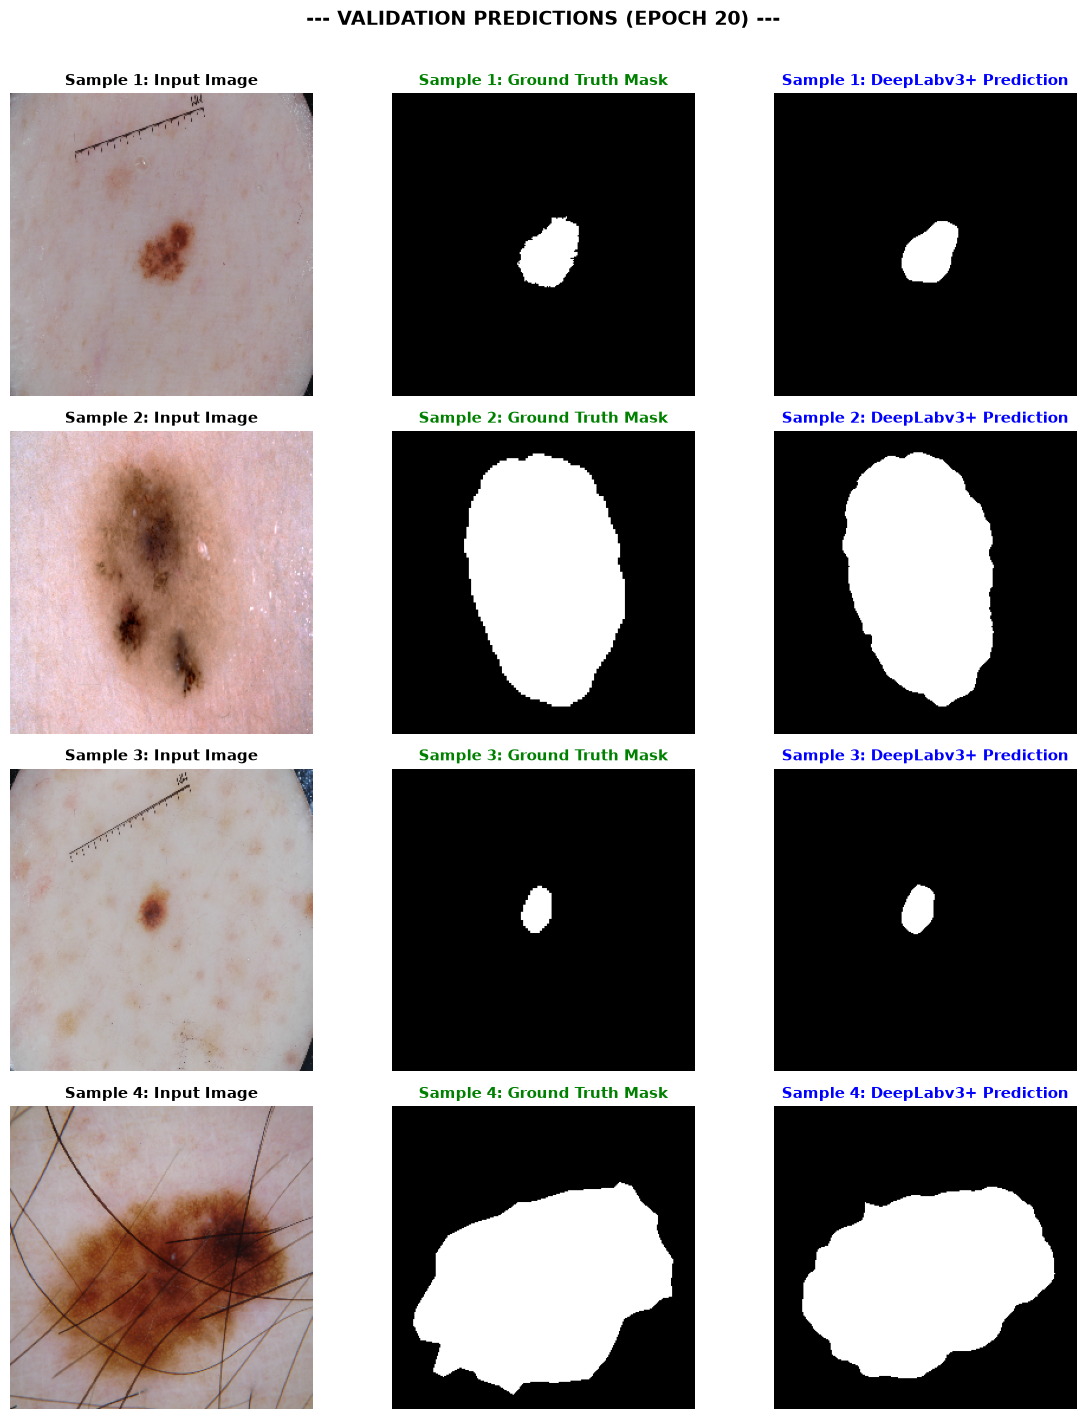

Hoàn thành huấn luyện trong 13.21 phút. Best Val Dice: 0.8986


In [21]:
# 1. Khởi tạo DataLoaders
train_loader, val_loader, test_loader = get_dataloaders(batch_size=config["batch_size"], num_workers=0)

# 2. Khởi tạo mô hình DeepLabv3+
model = DeepLabv3Plus(
    backbone_name=config["backbone"],
    pretrained=True,
    num_classes=1,
    output_stride=config["output_stride"],
    multi_grid=config["multi_grid"]
).to(device)

# 3. Phân tách tham số cho Differential Learning Rates
backbone_params = [p for n, p in model.named_parameters() if p.requires_grad and ("encoder_aspp" not in n and "decoder" not in n)]
head_params = [p for n, p in model.named_parameters() if p.requires_grad and ("encoder_aspp" in n or "decoder" in n)]

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": config["backbone_lr"], "weight_decay": config["weight_decay"]},
    {"params": head_params, "lr": config["head_lr"], "weight_decay": config["weight_decay"]}
])

# 4. Thiết lập PolyLR Scheduler theo số epoch
scheduler = PolyLRScheduler(
    optimizer,
    base_lrs=[config["backbone_lr"], config["head_lr"]],
    max_iters=config["epochs"],
    power=config["power"]
)

# 5. Huấn luyện mô hình
history, best_model_path = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=config["epochs"],
    patience=config["patience"],
    criterion=combined_loss,
    save_dir=config["save_dir"],
    use_amp=True
)


---
## 9. Trực quan hóa đường cong huấn luyện (Training Curves)


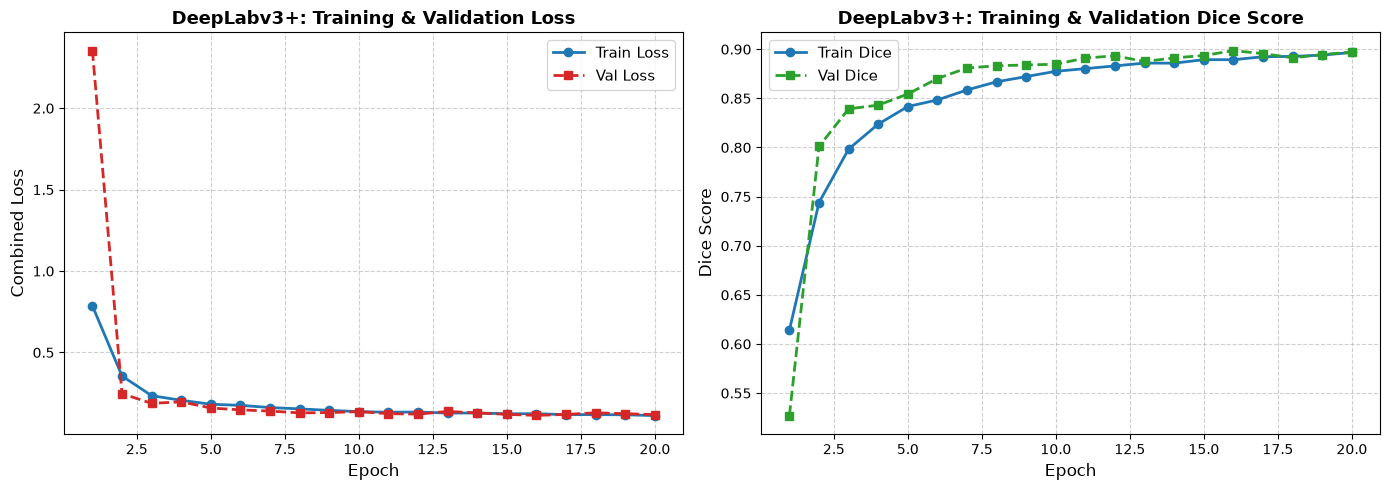

In [22]:
# Vẽ đồ thị Loss và Dice Score qua các Epochs
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(14, 5))

# Đồ thị Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], 'o-', label="Train Loss", color="tab:blue", linewidth=2)
plt.plot(epochs_range, history["val_loss"], 's--', label="Val Loss", color="tab:red", linewidth=2)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Combined Loss", fontsize=12)
plt.title("DeepLabv3+: Training & Validation Loss", fontsize=13, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)

# Đồ thị Dice Score
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_dice"], 'o-', label="Train Dice", color="tab:blue", linewidth=2)
plt.plot(epochs_range, history["val_dice"], 's--', label="Val Dice", color="tab:green", linewidth=2)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Dice Score", fontsize=12)
plt.title("DeepLabv3+: Training & Validation Dice Score", fontsize=13, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()


---
## 10. Đánh giá chi tiết trên tập Test (Full Test Evaluation)

Đánh giá đầy đủ 6 chỉ số trên toàn bộ 520 mẫu của tập Test:
- **Dice Score / F1**
- **IoU (Jaccard)**
- **Sensitivity / Recall** (Khả năng phát hiện tổn thương da)
- **Specificity** (Nhận diện da lành, tránh dương tính giả)
- **Precision**
- **Pixel Accuracy**



BẮT ĐẦU ĐÁNH GIÁ TRÊN TẬP TEST VỚI CHECKPOINT DEEPLABV3+


[Testing Full Metrics]: 100%|██████████| 33/33 [00:10<00:00,  3.28it/s]



KẾT QUẢ ĐÁNH GIÁ TOÀN BỘ CHỈ SỐ TRÊN TẬP TEST (DEEPLABV3+):
   Dice Score (F1)    : 0.8891 ± 0.1167
   IoU (Jaccard)      : 0.8161 ± 0.1523
   Sensitivity/Recall : 0.9137 ± 0.1225  (Bắt tổn thương)
   Specificity        : 0.9626 ± 0.0833  (Nhận diện da lành)
   Precision          : 0.8964 ± 0.1449
   Pixel Accuracy     : 0.9573 ± 0.0636
   Tổng số mẫu test   : 520



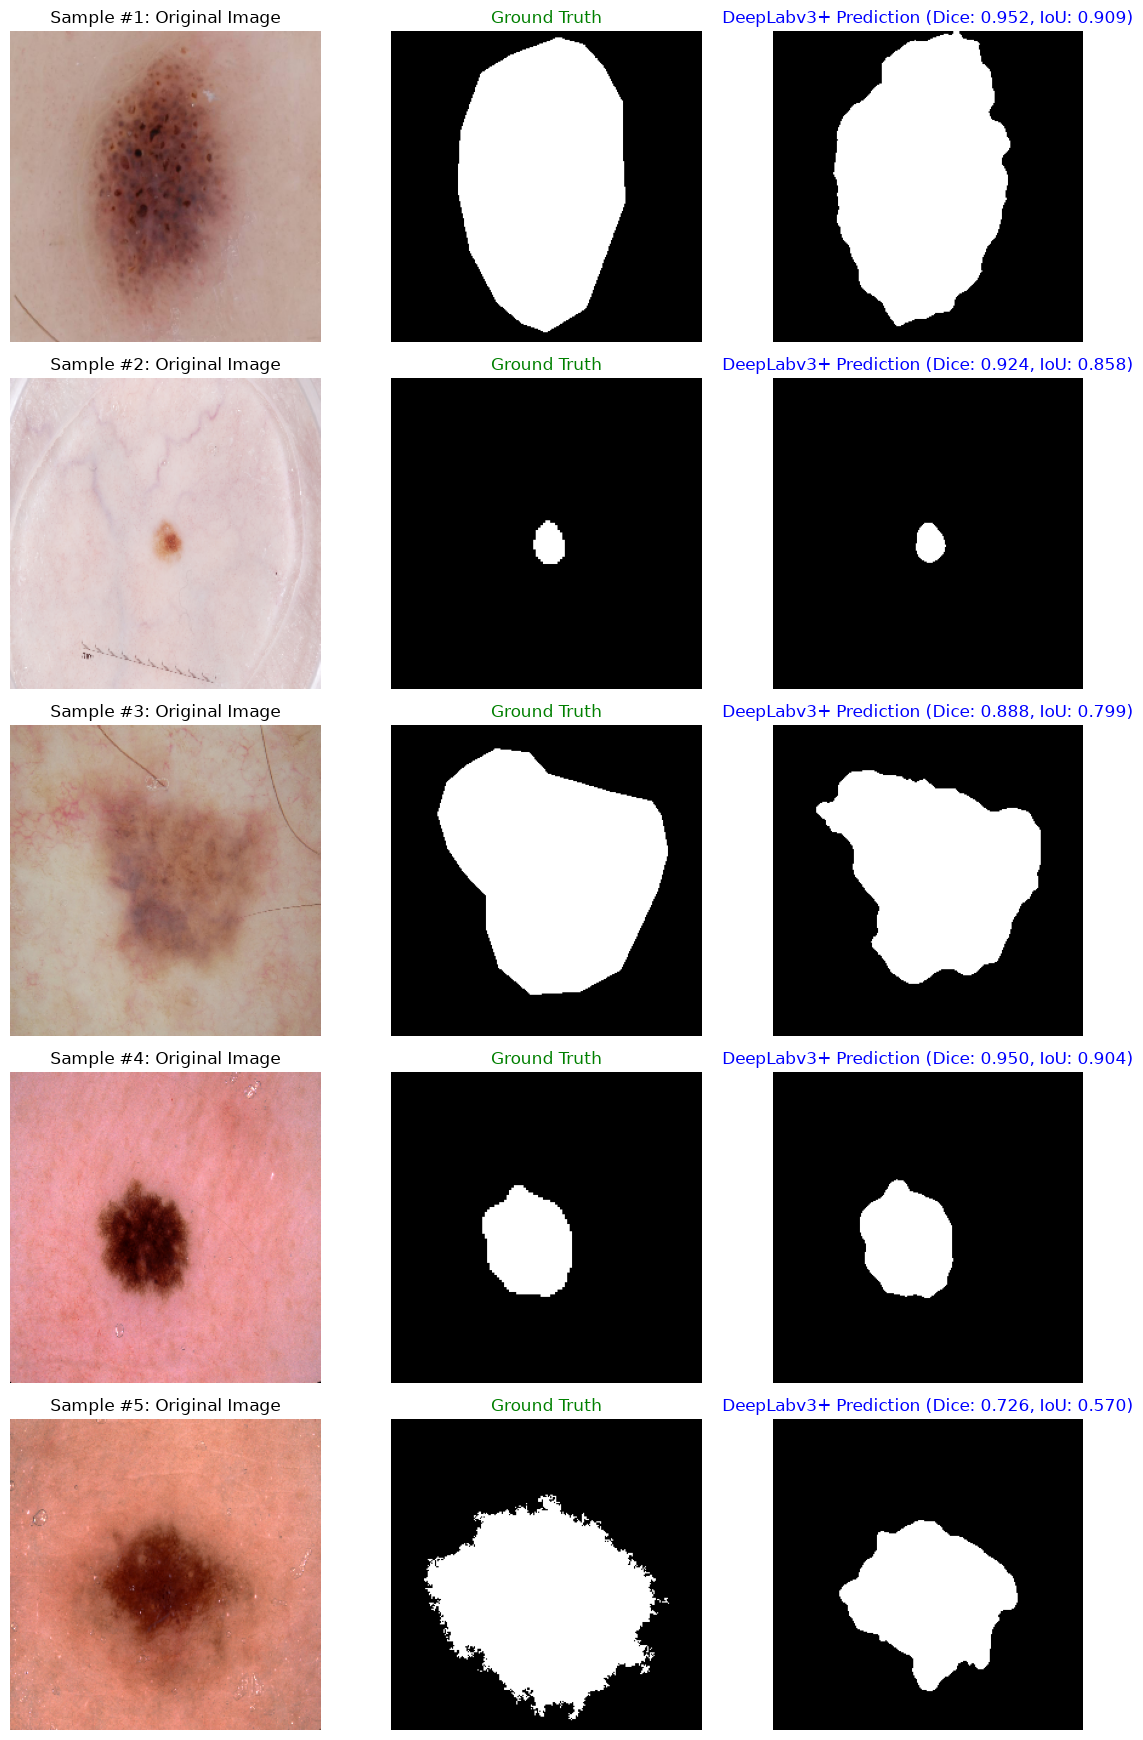

In [23]:
def evaluate_test_full_metrics(
    model,
    test_loader,
    model_path,
    device,
    num_visualize=5,
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
):
    print(f"\n{'=' * 65}")
    print("BẮT ĐẦU ĐÁNH GIÁ TRÊN TẬP TEST VỚI CHECKPOINT DEEPLABV3+")
    print(f"{'=' * 65}")

    # 1. Nạp checkpoint trọng số tốt nhất
    ckpt = torch.load(model_path, map_location=device)
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    elif isinstance(ckpt, dict) and "state_dict" in ckpt:
        model.load_state_dict(ckpt["state_dict"])
    elif isinstance(ckpt, dict):
        model.load_state_dict(ckpt)
    else:
        model.load_state_dict(ckpt)

    model.to(device)
    model.eval()

    all_metrics = {
        "dice": [],
        "iou": [],
        "sensitivity": [],
        "specificity": [],
        "precision": [],
        "accuracy": [],
    }

    mean_arr = np.array(mean, dtype=np.float32)
    std_arr = np.array(std, dtype=np.float32)
    sample_count = 0
    visualized_samples = []

    with torch.no_grad():
        for batch_data in tqdm(test_loader, desc="[Testing Full Metrics]"):
            if isinstance(batch_data, (list, tuple)) and len(batch_data) >= 2 and isinstance(batch_data[1], torch.Tensor):
                images = batch_data[0].to(device)
                masks = batch_data[1].to(device)
                has_gt = True
            else:
                images = batch_data[0].to(device) if isinstance(batch_data, (list, tuple)) else batch_data.to(device)
                masks = None
                has_gt = False

            outputs = model(images)
            logits = outputs["out"] if isinstance(outputs, dict) else (outputs[0] if isinstance(outputs, tuple) else outputs)
            preds = (torch.sigmoid(logits) > 0.5).float()

            for b in range(images.size(0)):
                img_np = images[b].cpu().permute(1, 2, 0).numpy()
                img_orig = np.clip((img_np * std_arr + mean_arr) * 255.0, 0, 255).astype(np.uint8)
                pred_np = (preds[b].squeeze().cpu().numpy() > 0).astype(np.uint8)

                if has_gt:
                    gt_np = (masks[b].squeeze().cpu().numpy() > 0).astype(np.uint8)
                    m = compute_all_metrics(pred_np, gt_np)
                else:
                    gt_np = np.zeros_like(pred_np)
                    m = {k: 0.0 for k in all_metrics}

                for k in all_metrics:
                    all_metrics[k].append(m[k])
                sample_count += 1

                if len(visualized_samples) < num_visualize:
                    visualized_samples.append((img_orig, gt_np, pred_np, m if has_gt else None))

    # 2. Tính trung bình và độ lệch chuẩn
    final_means = {f"test/{k}": round(float(np.mean(v)), 4) for k, v in all_metrics.items()}
    final_stds = {f"test/{k}_std": round(float(np.std(v)), 4) for k, v in all_metrics.items()}

    # 3. In kết quả tổng hợp
    print(f"\n{'=' * 65}")
    print("KẾT QUẢ ĐÁNH GIÁ TOÀN BỘ CHỈ SỐ TRÊN TẬP TEST (DEEPLABV3+):")
    print(f"   Dice Score (F1)    : {final_means['test/dice']:.4f} ± {final_stds['test/dice_std']:.4f}")
    print(f"   IoU (Jaccard)      : {final_means['test/iou']:.4f} ± {final_stds['test/iou_std']:.4f}")
    print(f"   Sensitivity/Recall : {final_means['test/sensitivity']:.4f} ± {final_stds['test/sensitivity_std']:.4f}  (Bắt tổn thương)")
    print(f"   Specificity        : {final_means['test/specificity']:.4f} ± {final_stds['test/specificity_std']:.4f}  (Nhận diện da lành)")
    print(f"   Precision          : {final_means['test/precision']:.4f} ± {final_stds['test/precision_std']:.4f}")
    print(f"   Pixel Accuracy     : {final_means['test/accuracy']:.4f} ± {final_stds['test/accuracy_std']:.4f}")
    print(f"   Tổng số mẫu test   : {sample_count}")
    print(f"{'=' * 65}\n")

    # 4. Trực quan hóa mẫu kết quả
    if num_visualize > 0 and len(visualized_samples) > 0:
        n = len(visualized_samples)
        fig, axes = plt.subplots(n, 3, figsize=(12, 3.5 * n))
        if n == 1:
            axes = np.expand_dims(axes, 0)

        for i, (img, gt, pred, m) in enumerate(visualized_samples):
            axes[i, 0].imshow(img)
            axes[i, 0].set_title(f"Sample #{i+1}: Original Image")
            axes[i, 0].axis("off")

            axes[i, 1].imshow(gt, cmap="gray")
            axes[i, 1].set_title("Ground Truth", color="green")
            axes[i, 1].axis("off")

            title_pred = "DeepLabv3+ Prediction"
            if m is not None:
                title_pred += f" (Dice: {m['dice']:.3f}, IoU: {m['iou']:.3f})"
            axes[i, 2].imshow(pred, cmap="gray")
            axes[i, 2].set_title(title_pred, color="blue")
            axes[i, 2].axis("off")

        plt.tight_layout()
        plt.show()

    return final_means, final_stds

# Thực hiện đánh giá với checkpoint tốt nhất
eval_means, eval_stds = evaluate_test_full_metrics(
    model=model,
    test_loader=test_loader,
    model_path=best_model_path,
    device=device,
    num_visualize=5
)
